# Merge IRGA datasets

# Imports

In [1]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats
import seaborn as sns

from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.pkgs.flux.hqflux import analyze_highest_quality_flux
from diive.pkgs.fluxprocessingchain.fluxprocessingchain import FluxProcessingChain
from diive.pkgs.fluxprocessingchain.fluxprocessingchain import LoadEddyProOutputFiles

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


# Load IRGA75 data (2004-2015)

In [2]:
FILEPATH = Path(r"31_SELF-HEATING_CORRECTION/42_FLUXES_L11_SHC_IRGA75+METEO7_2004-2017_2019.parquet")
df75 = load_parquet(filepath=FILEPATH)
df75 = df75.loc[df75.index.year <= 2015].copy()
df75

Loaded .parquet file 31_SELF-HEATING_CORRECTION\42_FLUXES_L11_SHC_IRGA75+METEO7_2004-2017_2019.parquet (0.493 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,W_UNROT,W_U_COV,W_VM97_TEST,W_ZCD,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2004-03-30 14:45:00,1005.41,1.12844,0.025668,1134.55,0.0,1.0,...,-0.227060,-0.209191,800000001.0,14.0,-1.260300,-1.311810
2004-03-30 15:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-30 15:45:00,1005.42,1.12663,0.025709,1132.74,0.0,1.0,...,-0.063026,0.002830,800000001.0,39.0,-0.350351,-0.361224
2004-03-30 16:15:00,1005.43,1.12587,0.025726,1131.98,0.0,1.0,...,-0.028456,-0.034904,800000000.0,76.0,-0.295734,-0.304238
2004-03-30 16:45:00,1005.44,1.12521,0.025742,1131.33,0.0,1.0,...,0.371090,-0.012976,800000000.0,247.0,-0.702368,-0.729167
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-31 21:45:00,1009.67,1.18055,0.024458,1191.97,0.0,1.0,...,-0.006454,0.016795,800000011.0,4150.0,0.522212,0.529144
2015-12-31 22:15:00,1009.69,1.18042,0.024461,1191.86,0.0,1.0,...,0.126286,0.009084,800000111.0,1838.0,-0.451086,-0.471095
2015-12-31 22:45:00,1009.69,1.18033,0.024463,1191.77,0.0,1.0,...,0.201233,-0.017653,800000011.0,1127.0,-1.325260,-0.316928


# Load IRGA72 data (2016-2024)

In [3]:
FILEPATH = Path(r"../20_MERGE_DATA/22.4_FLUXES_L1_IRGA72+METEO7_2016-2024.parquet")
df72 = load_parquet(filepath=FILEPATH)
df72 = df72.loc[df72.index.year >= 2016]
df72

Loaded .parquet file ..\20_MERGE_DATA\22.4_FLUXES_L1_IRGA72+METEO7_2016-2024.parquet (0.250 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,W_UNROT,W_U_COV,W_VM97_TEST,W_ZCD,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2016-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-01 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,1008.09,1.20135,0.024060,1211.07,0.0,1.0,...,-0.138079,0.016036,800000000.0,21.0,-0.178429,-0.179257
2024-12-31 22:15:00,1008.14,1.20010,0.024085,1209.87,0.0,1.0,...,-0.005790,-0.118170,800000000.0,8.0,-0.316167,-0.321022
2024-12-31 22:45:00,1008.20,1.20023,0.024081,1210.07,0.0,1.0,...,0.065927,-0.196501,800000000.0,9.0,-0.101105,-0.102196


# Merge

In [4]:
df = pd.concat([df75, df72], axis=0)
df

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,BADM_INST_GA_CP_TUBE_LENGTH_GA_H2O,CUSTOM_CO2_MEAN,CUSTOM_COOLER_V_MEAN,CUSTOM_H2O_MEAN,MV_AIR_CELL_CO2,MV_AIR_CELL_H2O
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2004-03-30 14:45:00,1005.41,1.12844,0.025668,1134.55,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-30 15:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-30 15:45:00,1005.42,1.12663,0.025709,1132.74,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-30 16:15:00,1005.43,1.12587,0.025726,1131.98,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-30 16:45:00,1005.44,1.12521,0.025742,1131.33,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,1008.09,1.20135,0.024060,1211.07,0.0,1.0,...,100.0,19.0892,1.82424,188.217,0.023859,0.023859
2024-12-31 22:15:00,1008.14,1.20010,0.024085,1209.87,0.0,1.0,...,100.0,19.0172,1.82389,191.061,0.023859,0.023859
2024-12-31 22:45:00,1008.20,1.20023,0.024081,1210.07,0.0,1.0,...,100.0,19.0845,1.82305,196.751,0.023856,0.023856


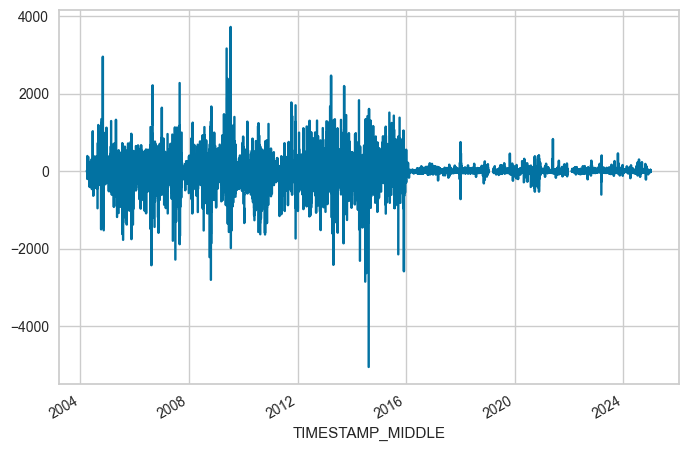

In [5]:
# [print(c) for c in df.columns if "TA" in c];
df['FC'].plot(x_compat=True);

# Save to file

In [6]:
save_parquet(data=df, filename="31.2_FLUXES_IRGA75-L1.1+IRGA72-L1+METEO7_2004-2024")

Saved file 31.2_FLUXES_IRGA75-L1.1+IRGA72-L1+METEO7_2004-2024.parquet (4.676 seconds).


'31.2_FLUXES_IRGA75-L1.1+IRGA72-L1+METEO7_2004-2024.parquet'

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# ✅END OF NOTEBOOK

Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [7]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-12-05 22:07:02
